In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

In [17]:
df = pd.read_csv('numbered_mpc.csv')

Text(0, 0.5, 'Count')

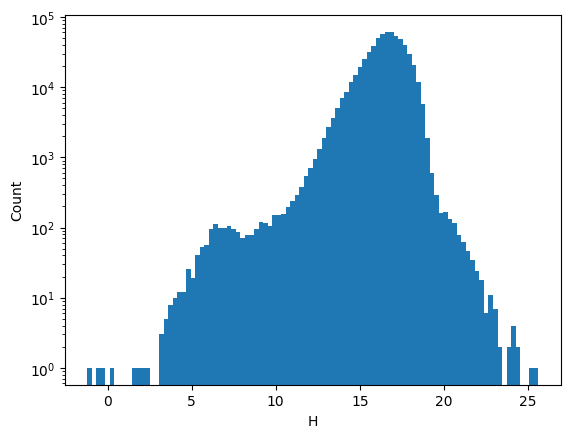

In [18]:
plt.hist(df['H'],bins=100)
plt.yscale('log')
plt.xlabel("H")
plt.ylabel("Count")

In [20]:
r=2.5
d=2.5
V = df['H'] + 5*np.log10(r*d)

### Limiting Mag is ~17 (optimistically)
https://hea-www.harvard.edu/DASCH/papers/coverage6041/aavso5.pdf

We have about 10^4 asteroids to check.

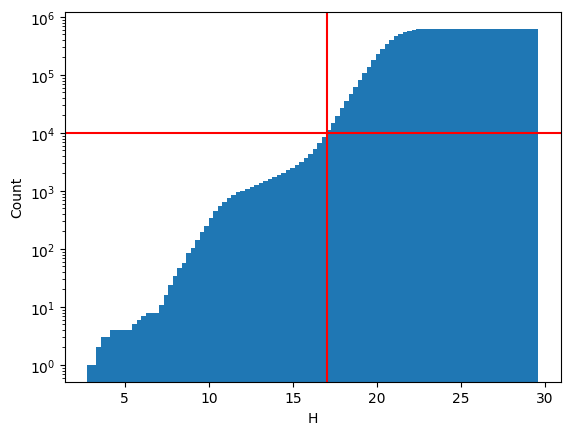

In [23]:
plt.hist(V,bins=100,cumulative=True)
plt.yscale('log')
plt.xlabel("H")
plt.ylabel("Count")
plt.axvline(17,c='r')
plt.axhline(1e4,c='r')

In [26]:
bright_df = df[V < 17]
bright_df

,desgs,epoch,M,omega,Omega,inc,ecc,a,H
0,1,2023-02-25,17.21569,73.47045,80.26013,10.58635,0.078817,2.767182,3.33
1,2,2023-02-25,357.84942,310.86479,172.91814,34.92703,0.230084,2.769632,4.12
2,3,2023-02-25,351.82414,247.73655,169.84298,12.99067,0.256468,2.670137,5.16
3,4,2023-02-25,115.13301,151.59911,103.75733,7.13926,0.088758,2.363038,3.22
4,5,2023-02-25,256.02913,358.88647,141.52285,5.36013,0.187924,2.578698,7.00
...,...,...,...,...,...,...,...,...,...
620073,620074,2023-02-25,70.58188,68.74885,304.57152,28.08164,0.426507,61.966178,4.92
620074,620075,2023-02-25,184.94746,261.36824,73.47549,5.27591,0.229404,39.238838,5.78
620085,620086,2023-02-25,28.83875,297.03260,122.22147,27.59853,0.445713,63.634005,6.73
620086,620087,2023-02-25,7.19088,314.53725,191.84600,17.52496,0.422701,58.569158,7.47


## Now limit to main belt (no KBOs, they won't move!) -> 6000 members

In [32]:
target_df = bright_df[bright_df['a'] < 5.0]
target_df

,desgs,epoch,M,omega,Omega,inc,ecc,a,H
0,1,2023-02-25,17.21569,73.47045,80.26013,10.58635,0.078817,2.767182,3.33
1,2,2023-02-25,357.84942,310.86479,172.91814,34.92703,0.230084,2.769632,4.12
2,3,2023-02-25,351.82414,247.73655,169.84298,12.99067,0.256468,2.670137,5.16
3,4,2023-02-25,115.13301,151.59911,103.75733,7.13926,0.088758,2.363038,3.22
4,5,2023-02-25,256.02913,358.88647,141.52285,5.36013,0.187924,2.578698,7.00
...,...,...,...,...,...,...,...,...,...
95951,95952,2023-02-25,129.60862,309.75357,84.85928,7.10219,0.287904,3.963277,12.88
99876,99877,2023-02-25,189.98276,25.49252,347.19485,14.26802,0.272618,3.953757,13.01
115439,115440,2023-02-25,152.07104,318.14741,68.42432,14.31099,0.173480,3.967425,12.79
131428,131429,2023-02-25,260.88927,165.15556,291.74943,22.32477,0.135103,3.043072,12.97


In [34]:
target_df.to_csv("targets.csv",index=False)